# Импорт библиотек

In [67]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import selectKBest, selectRFE, drawSelection

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint
import xgboost as xgb

# Считывание данных

In [140]:
df = pd.read_csv('data/processed.csv')
df.shape

(1001, 194)

# Очистка таргета от выбросов

(940, 194)


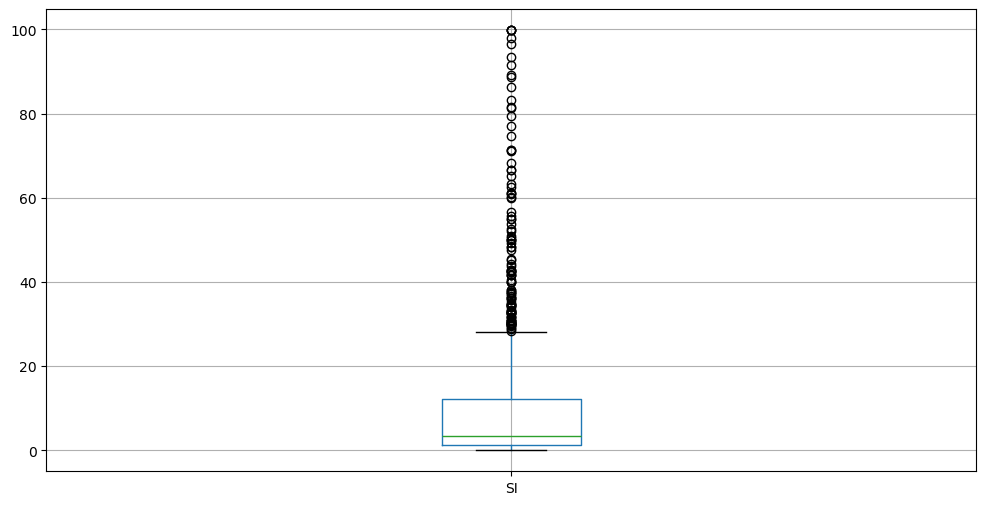

In [142]:
df = df[df['SI'] < 100]
print(df.shape)
df.boxplot(column=['SI'], figsize=(12, 6))
plt.show()

In [144]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['SI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (752, 191), (752,)
Test dataset size: (188, 191), (188,)


# Эксперемент с различными моделями

In [146]:
lig_reg = LinearRegression()
tree = DecisionTreeRegressor()
knn = KNeighborsRegressor(2)
randomForest = RandomForestRegressor(n_estimators=100, random_state=42)

lig_reg.fit(X_train, y_train)
tree.fit(X_train, y_train)
knn.fit(X_train, y_train)
randomForest.fit(X_train, y_train)

y_pred_lig = lig_reg.predict(X_test)
y_pred_tree = tree.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_randomForest = randomForest.predict(X_test)

print('LinearRegression:')
print(f'* Mean Absolute Error: {mean_absolute_error(y_test, y_pred_lig)}')
print(f'* R2 score: {r2_score(y_test, y_pred_lig)}')

print('DecisionTreeRegressor:')
print(f'* Mean Absolute Error: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'* R2 score: {r2_score(y_test, y_pred_tree)}')

print('KNeighborsRegressor:')
print(f'* Mean Absolute Error: {mean_absolute_error(y_test, y_pred_knn)}')
print(f'* R2 score: {r2_score(y_test, y_pred_knn)}')

print('RandomForestRegressor:')
print(f'* Mean Absolute Error: {mean_absolute_error(y_test, y_pred_randomForest)}')
print(f'* R2 score: {r2_score(y_test, y_pred_randomForest)}')

LinearRegression:
* Mean Absolute Error: 11.801939459436678
* R2 score: -0.2533192406527274
DecisionTreeRegressor:
* Mean Absolute Error: 10.869798883818538
* R2 score: -0.44530708504257643
KNeighborsRegressor:
* Mean Absolute Error: 9.786174972468983
* R2 score: -0.12324193380962845
RandomForestRegressor:
* Mean Absolute Error: 8.629069007587168
* R2 score: 0.21070080108566358


# Фильтрация признаков

In [148]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='mae')

In [150]:
kbest_mae_scores, kbest_r2_scores, kbest_selected_features_list = selectKBest(model, X_train, X_test, y_train, y_test)

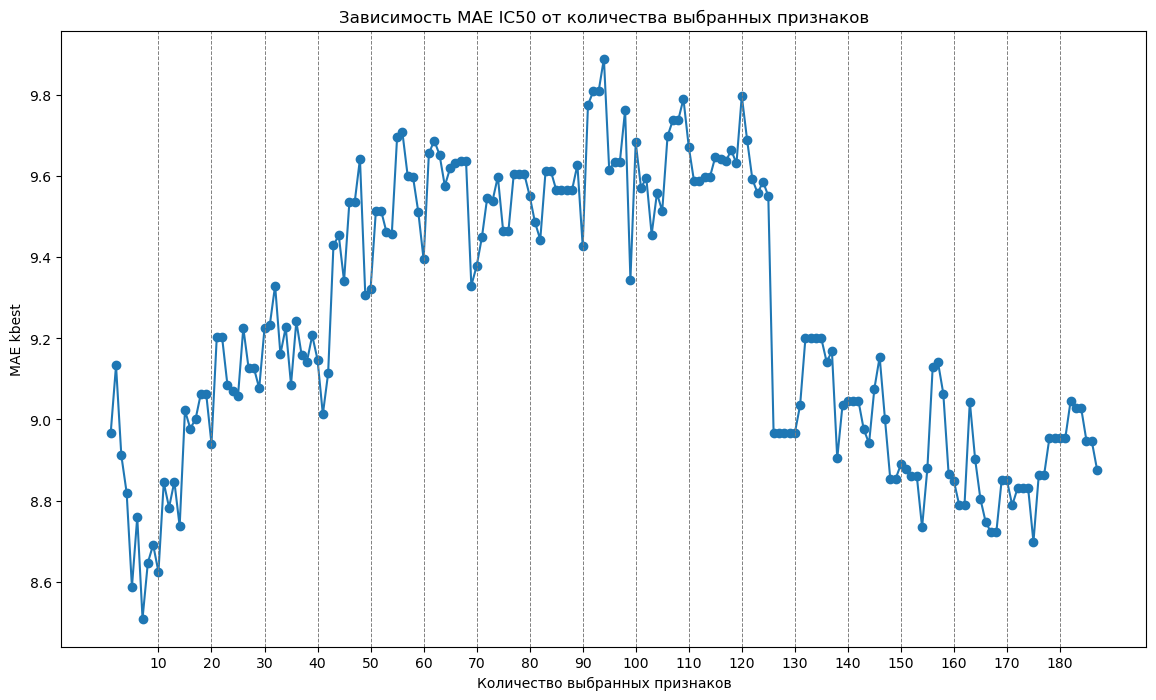

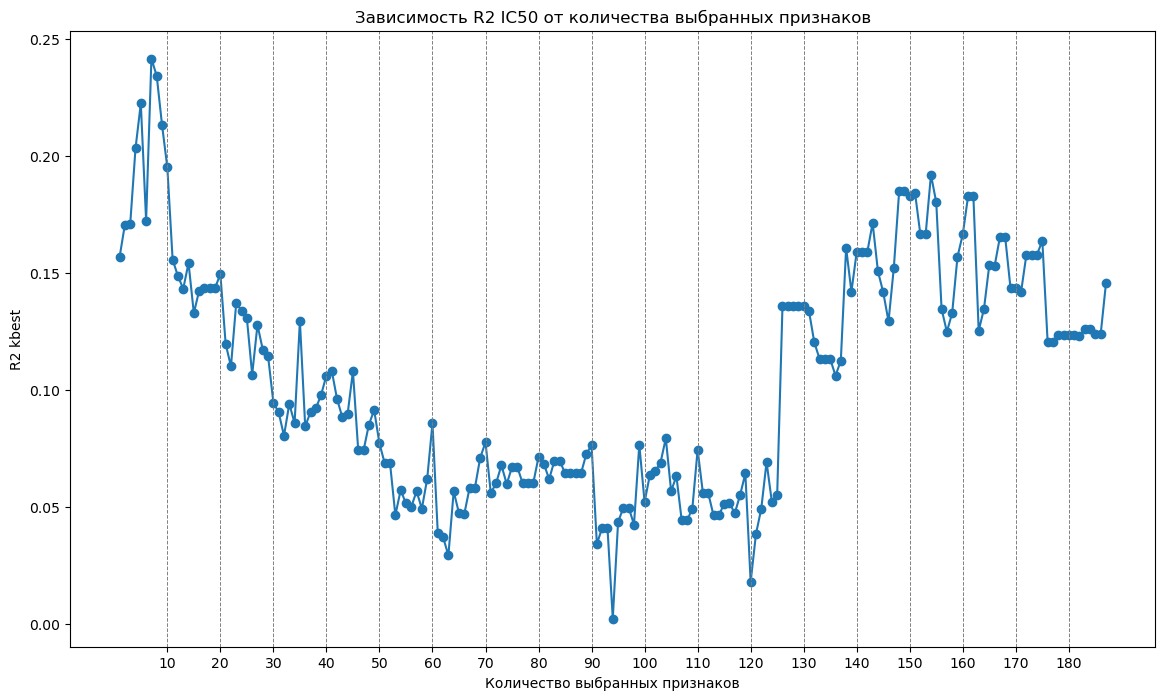

In [151]:
drawSelection(kbest_mae_scores, 'MAE', 'IC50', 'kbest')
drawSelection(kbest_r2_scores, 'R2', 'IC50', 'kbest')

По методу SelectKBest оптимальное количество признаков - 7

In [154]:
selected_features = kbest_selected_features_list[6]
rfe_mae_scores, rfe_r2_scores, rfe_selected_features_list = selectRFE(model, X_train[selected_features], X_test[selected_features], y_train, y_test)

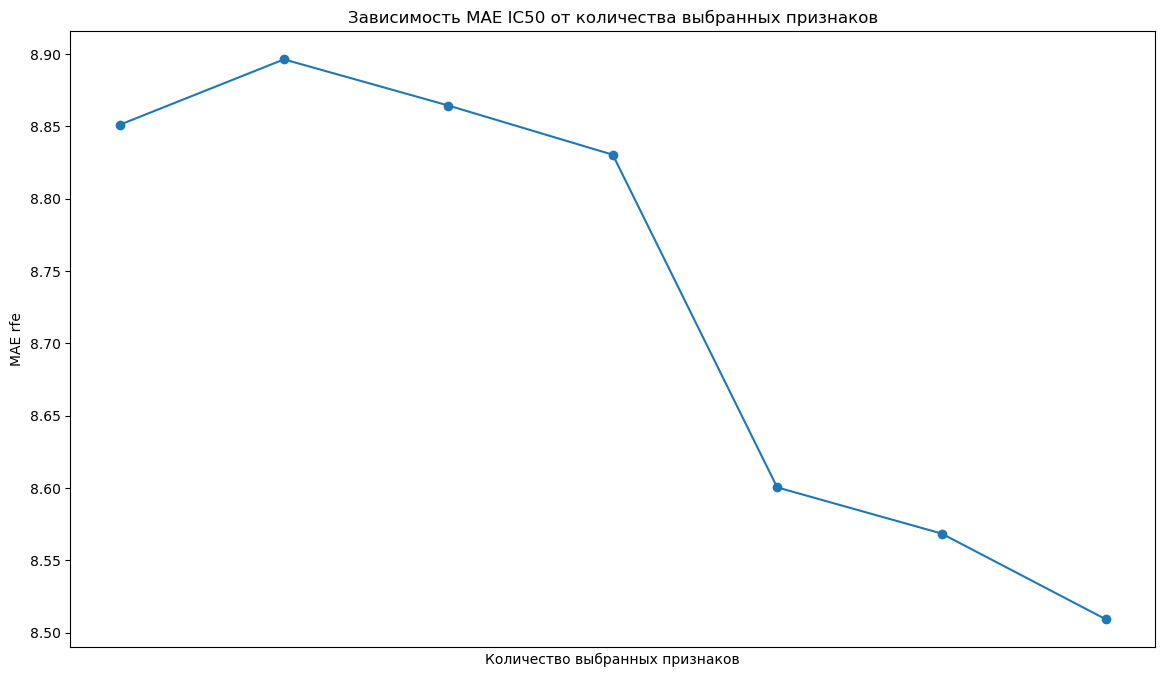

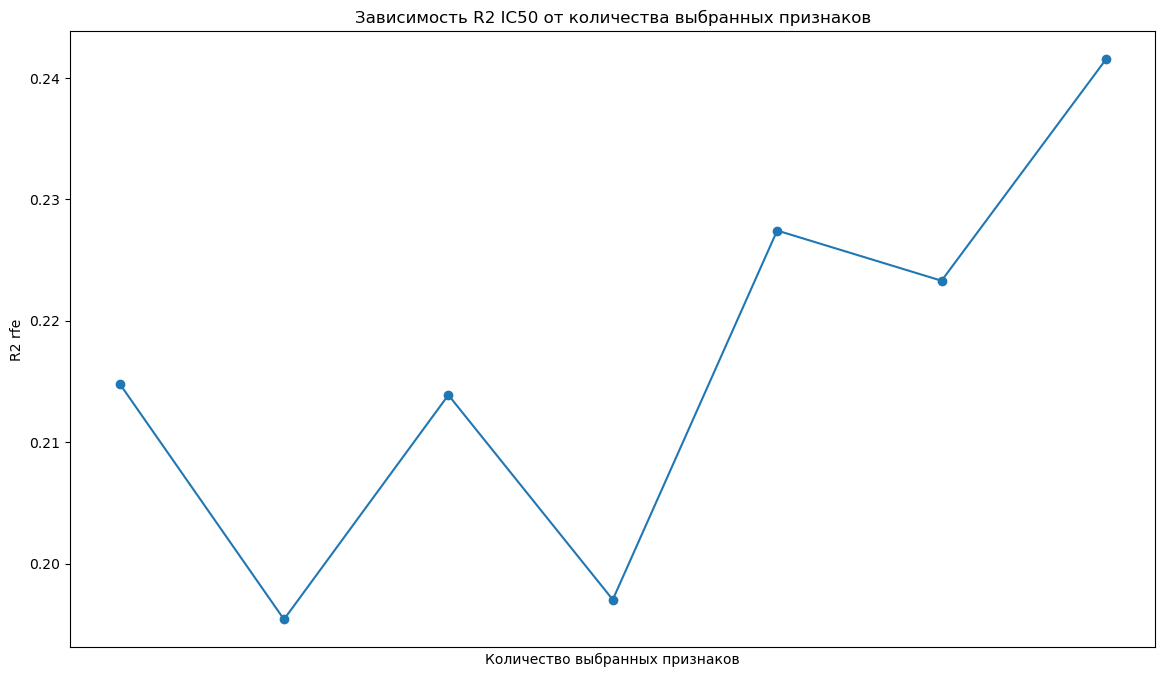

In [156]:
drawSelection(rfe_mae_scores, 'MAE', 'IC50', 'rfe')
drawSelection(rfe_r2_scores, 'R2', 'IC50', 'rfe')

По методу RFE оптимальное количество признаков - 7

In [158]:
selected_features = rfe_selected_features_list[6]

Сравним работу одной и той же модели на всех признаках и на отфильтрованных

In [160]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Все признаки')
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

print('\n')
print('Отфильтрованные признаки')
model.fit(X_train[selected_features], y_train)
y_pred = model.predict(X_test[selected_features])
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Все признаки
Mean Absolute Error: 8.876157465726727
R^2 Score: 0.14543971867739092


Отфильтрованные признаки
Mean Absolute Error: 8.509232022459956
R^2 Score: 0.24152496948283464


# Подбор гиперпараметров

In [184]:
param_dist = {
    'n_estimators': randint(10, 200),
    'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'eval_metric': ['mae'],
    'objective': ['reg:squarederror'],
}
random_search = RandomizedSearchCV(xgb.XGBRegressor(), param_distributions=param_dist, n_iter=100, cv=4, scoring='r2', n_jobs=-1, random_state=42)
random_search.fit(X_train[selected_features], y_train)

print("Лучшие параметры:", random_search.best_params_)

y_pred = random_search.predict(X_test[selected_features])

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Лучшие параметры: {'eval_metric': 'mae', 'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 143, 'objective': 'reg:squarederror'}
Mean Absolute Error: 9.411081622245339
R2 score: 0.21158578650312587


In [164]:
param_dist = {
    'n_estimators': randint(10, 100),
    'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}
random_search = RandomizedSearchCV(RandomForestRegressor(), param_distributions=param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=42)
random_search.fit(X_train[selected_features], y_train)

print("Лучшие параметры:", random_search.best_params_)

y_pred = random_search.predict(X_test[selected_features])

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Лучшие параметры: {'bootstrap': True, 'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 36}
Mean Absolute Error: 9.14343974050161
R2 score: 0.1777822076994522


In [166]:
param_distributions = {
    'n_neighbors': randint(1, 10),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

random_search = RandomizedSearchCV(
    estimator=KNeighborsRegressor(),
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)
random_search.fit(X_train[selected_features], y_train)

print("Лучшие параметры:", random_search.best_params_)

y_pred = random_search.predict(X_test[selected_features])

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Mean Absolute Error: 9.111508303012721
Mean Squared Error: 195.07292787759297
R2 score: 0.1136100168238725


# Лучшая модель

In [190]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='mae')
model.fit(X_train[selected_features], y_train)
y_pred = model.predict(X_test[selected_features])
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")
print(selected_features)

Mean Absolute Error: 8.509232022459956
R^2 Score: 0.24152496948283464
Index(['SMR_VSA5', 'SMR_VSA7', 'SlogP_VSA5', 'SlogP_VSA6', 'VSA_EState6',
       'VSA_EState8', 'FractionCSP3', 'NumAromaticRings', 'fr_Imine', 'fr_NH2',
       'fr_allylic_oxid'],
      dtype='object')


Итого, лучшая модель XGBRegressor, лучше всего работает на признаках: 'SMR_VSA5', 'SMR_VSA7', 'SlogP_VSA5', 'SlogP_VSA6', 'VSA_EState6', 'VSA_EState8', 'FractionCSP3', 'NumAromaticRings', 'fr_Imine', 'fr_NH2', 'fr_allylic_oxid'

R2 0.24, mae 8.5

0       0.000
1       0.001
2       0.002
3       0.003
4       0.004
        ...  
996     0.996
997     0.997
998     0.998
999     0.999
1000    1.000
Name: Unnamed: 0, Length: 940, dtype: float64